In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [14]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [28]:
# Load CSV files
wt = pd.read_csv("/Users/juliemcdonald/Documents/flamholz_lab/RNASeq_testing/wt/wt_final_gene_counts.csv")
lim = pd.read_csv("/Users/juliemcdonald/Documents/flamholz_lab/RNASeq_testing/lim/lim_final_gene_counts.csv")

# Rename count columns before merging
wt = wt.rename(columns={"TPM": "wt_TPM"})
lim = lim.rename(columns={"TPM": "lim_TPM"})

# Merge on shared gene info columns (outer join keeps all genes from both files)
merged = pd.merge(
    wt[["gene_id", "Chr", "Product", "Name", "wt_TPM"]],
    lim[["gene_id", "lim_TPM"]],
    on="gene_id",
    how="inner"
)

# Reorder columns
merged = merged[["gene_id", "Chr", "Product", "Name", "wt_TPM", "lim_TPM"]]

# Save to Excel
merged.to_csv("merged_gene_TPM.csv", index=False)

print(f"Done! {len(merged)} genes written to merged_gene_TPM.csv")

Done! 4380 genes written to merged_gene_TPM.csv


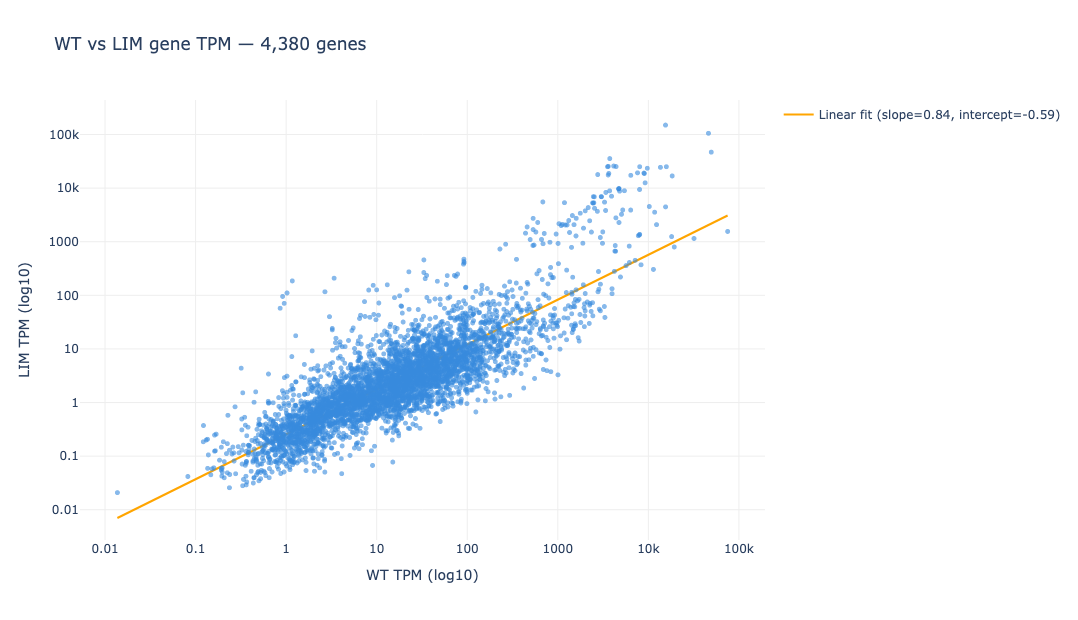

Saved: scatter_wt_vs_lim.html


In [29]:
import plotly.express as px

# Keep only genes with counts > 0 in both conditions
df = merged[(merged.wt_TPM > 0) & (merged.lim_TPM > 0)].copy()

# Plot
fig = px.scatter(
    df,
    x="wt_TPM",
    y="lim_TPM",
    hover_name="Name",
    hover_data={"Name": True, "gene_id": True, "Product": True, "Chr": True,
                "wt_TPM": True, "lim_TPM": True},
    log_x=True,
    log_y=True,
    opacity=0.6,
    labels={"wt_TPM": "WT TPM (log10)", "lim_TPM": "LIM TPM (log10)"},
    title=f"WT vs LIM gene TPM — {len(df):,} genes",
)

# 1:1 reference line
axis_min = min(df["wt_TPM"].min(), df["lim_TPM"].min())
axis_max = max(df["wt_TPM"].max(), df["lim_TPM"].max())


# Linear fit on log10-transformed values
log_wt = np.log10(df["wt_TPM"])
log_lim = np.log10(df["lim_TPM"])
coeffs = np.polyfit(log_wt, log_lim, 1)
slope, intercept = coeffs

x_fit = np.linspace(log_wt.min(), log_wt.max(), 200)
y_fit = slope * x_fit + intercept

fig.add_scatter(
    x=10**x_fit,
    y=10**y_fit,
    mode="lines",
    line=dict(color="orange", width=2),
    name=f"Linear fit (slope={slope:.2f}, intercept={intercept:.2f})",
)

fig.update_traces(marker=dict(size=5, color="#378ADD"))
fig.update_layout(
    width=750, height=620,
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#eeeeee"),
    yaxis=dict(showgrid=True, gridcolor="#eeeeee"),
)

# Works in Jupyter and also saves a standalone HTML file
fig.show()
fig.write_html("scatter_wt_vs_lim.html")
print("Saved: scatter_wt_vs_lim.html")

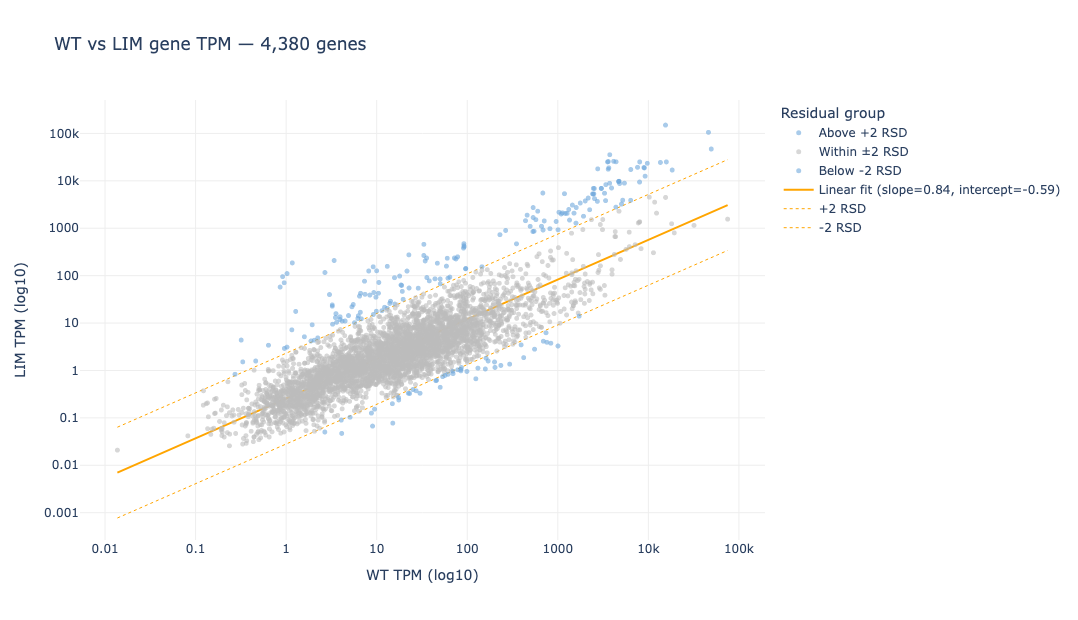

Saved: scatter_wt_vs_lim.html


In [34]:
import plotly.express as px
import numpy as np

# Keep only genes with counts > 0 in both conditions
df = merged[(merged.wt_TPM > 0) & (merged.lim_TPM > 0)].copy()

# --- Log10-transform for fitting ---
log_wt  = np.log10(df["wt_TPM"])
log_lim = np.log10(df["lim_TPM"])

# --- Linear fit ---
coeffs = np.polyfit(log_wt, log_lim, 1)
slope, intercept = coeffs

# --- Residuals & RSD threshold ---
predicted   = slope * log_wt + intercept
residuals   = log_lim - predicted
rsd         = residuals.std()

df["residual"] = residuals.values
df["color_group"] = np.where(
    residuals > 2 * rsd, "Above +2 RSD",
    np.where(residuals < - 2 * rsd, "Below -2 RSD", "Within ±2 RSD")
)

# --- Color map ---
color_map = {
    "Within ±2 RSD": "#bcbcbc",
    "Above +2 RSD":  "#6fa8dc",
    "Below -2 RSD":  "#6fa8dc",
}

# --- Plot ---
fig = px.scatter(
    df,
    x="wt_TPM",
    y="lim_TPM",
    color="color_group",
    color_discrete_map=color_map,
    hover_name="Name",
    hover_data={"Name": True, "gene_id": True, "Product": True, "Chr": True,
                "wt_TPM": True, "lim_TPM": True, "residual": ":.3f"},
    log_x=True,
    log_y=True,
    opacity=0.6,
    labels={"wt_TPM": "WT TPM (log10)", "lim_TPM": "LIM TPM (log10)",
            "color_group": "Residual group"},
    title=f"WT vs LIM gene TPM — {len(df):,} genes",
    category_orders={"color_group": ["Above +1 RSD", "Within ±1 RSD", "Below -1 RSD"]},
)

# --- 1:1 reference line (dashed grey) ---
x_fit = np.linspace(log_wt.min(), log_wt.max(), 200)
y_fit = slope * x_fit + intercept

fig.add_scatter(
    x=10**x_fit,
    y=10**y_fit,
    mode="lines",
    line=dict(color="orange", width=2),
    name=f"Linear fit (slope={slope:.2f}, intercept={intercept:.2f})",
)

# --- ±1 RSD envelope lines ---
for label, offset, dash in [
    ("+2 RSD", 2*rsd, "dot"),
    ("-2 RSD", -2*rsd, "dot"),
]:
    fig.add_scatter(
        x=10**x_fit,
        y=10**(y_fit + offset),
        mode="lines",
        line=dict(color="orange", width=1, dash=dash),
        name=label,
    )

fig.update_traces(marker=dict(size=5), selector=dict(mode="markers"))
fig.update_layout(
    width=750, height=620,
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#eeeeee"),
    yaxis=dict(showgrid=True, gridcolor="#eeeeee"),
)

fig.show()
fig.write_html("scatter_wt_vs_lim.html")
print("Saved: scatter_wt_vs_lim.html")